In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import time
warnings.filterwarnings("ignore")


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

In [3]:

df_final = pd.read_csv(r"C:\Users\pc\Desktop\project\tutorial_rdkit\models_prediction_solubulity\delaney_mordred_truncated.csv")

df_final.head()

,Compound ID,SMILES,measured log(solubility:mol/L),ABC,nBase,SpMAD_A,VR1_A,nAromAtom,nSpiro,nBridgehead,...,JGI3,JGI4,JGI5,JGI6,JGI7,JGI8,JGI9,JGI10,Lipinski,GhoseFilter
0,"1,1,1,2-Tetrachloroethane",ClCC(Cl)(Cl)Cl,-2.18,4.012290,0,0.969771,11.637367,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
1,"1,1,1-Trichloroethane",CC(Cl)(Cl)Cl,-2.00,3.464102,0,0.800000,8.000000,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
2,"1,1,2,2-Tetrachloroethane",ClC(Cl)C(Cl)Cl,-1.74,3.932653,0,1.000000,11.530010,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
3,"1,1,2-Trichloroethane",ClCC(Cl)Cl,-1.48,3.047207,0,1.045250,8.629874,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
4,"1,1,2-Trichlorotrifluoroethane",FC(F)(Cl)C(F)(Cl)Cl,-3.04,5.808525,0,0.901388,17.881697,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0


In [4]:
y = df_final['measured log(solubility:mol/L)']
X = pd.DataFrame(StandardScaler().fit_transform(df_final.iloc[:, 3:]), columns = df_final.iloc[:, 3:].columns)

                  
X.shape


(1144, 283)

In [5]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
print(f'The r2 score for train set is : {rf.score(X_train, y_train)}')
print(f'The r2 score for test set is : {rf.score(X_test, y_test)}')


The r2 score for train set is : 0.9832650936846883
The r2 score for test set is : 0.8938914691910151


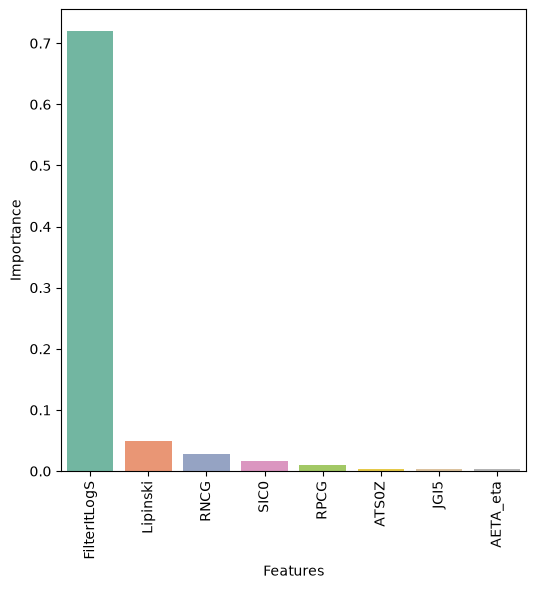

In [6]:
import seaborn  as sns 
importance = rf.feature_importances_
# summarize feature importance
dicts = {
    'Features':[x for x in df_final.iloc[:,3:].columns],
    'Importance':importance
    }
DF_imp = pd.DataFrame(dicts)
DF_imp = DF_imp.sort_values('Importance',ascending=False)
DF_imp.to_excel('imp.xlsx', index=None)

top_desc_fi = DF_imp[:8]
plt.subplots(figsize=(6,6))
sns.barplot(data=top_desc_fi, x = 'Features', y='Importance', palette = 'Set2')

plt.xticks(rotation = 90)
plt.show()


In [8]:
print(top_desc_fi.values)


[['FilterItLogS' 0.7161983965679224]
 ['Lipinski' 0.05193765495540378]
 ['RNCG' 0.028920349245491566]
 ['SIC0' 0.015926039713929366]
 ['RPCG' 0.0095207826191939]
 ['ATS0Z' 0.003335807148587512]
 ['PEOE_VSA6' 0.003208546111557596]
 ['RNCS' 0.0028270428078552693]]


In [7]:
df_final_8 = df_final[top_desc_fi['Features'].values[:8]]

df_final_8


,FilterItLogS,Lipinski,RNCG,SIC0,RPCG,ATS0Z,JGI5,AETA_eta
0,-2.790326,1,0.330754,0.500000,0.551252,1230,0.000000,0.941684
1,-2.129911,1,0.311690,0.520426,0.695189,942,0.000000,0.913440
2,-2.433986,1,0.250000,0.500000,0.335426,1230,0.000000,0.899987
3,-2.147371,1,0.372917,0.520426,0.364050,942,0.000000,0.776328
4,-2.664600,1,0.277752,0.520426,0.533222,1182,0.000000,0.875353
...,...,...,...,...,...,...,...,...
1139,-2.002619,1,0.208329,0.369507,0.225705,1348,0.020202,1.053662
1140,-3.677096,1,0.283208,0.390072,0.279375,1260,0.034028,0.716676
1141,-4.965356,1,0.252199,0.259156,0.170939,956,0.030805,0.718947
1142,-4.497400,1,0.235956,0.362121,0.136406,1454,0.044147,0.764417


In [8]:
df_new = pd.concat([df_final_8 , y]  ,  axis  =1)

df_new.to_csv( 'delaney_8_des.csv', index = None)

In [9]:
y = df_final['measured log(solubility:mol/L)']
X = pd.DataFrame(StandardScaler().fit_transform(df_final_8), columns = df_final_8.columns)


In [10]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
print(f'The r2 score for train set is : {rf.score(X_train, y_train)}')
print(f'The r2 score for test set is : {rf.score(X_test, y_test)}')

The r2 score for train set is : 0.9812972337495623
The r2 score for test set is : 0.8951666240760959


In [11]:

et = ExtraTreesRegressor()
et.fit(X_train, y_train)
print(f'The r2 score for train set is : {et.score(X_train, y_train)}')
print(f'The r2 score for test set is : {et.score(X_test, y_test)}')

The r2 score for train set is : 0.9991673086926451
The r2 score for test set is : 0.8975930265921627


**Rgressor means we subset the dataset to many smalldata and the model predict the output by each sample and fainaly it evaluate the predictions by the test**

**Now we have to finf the best params of our models by the Gridsearch and the randomsearch**

In [12]:
from sklearn.model_selection import GridSearchCV  , RandomizedSearchCV
rf = RandomForestRegressor(n_estimators=100,
                           bootstrap=True,# used the draw and sampling with replacement
                           max_depth=None,
                           max_features=1.0,
                           min_samples_leaf=1,
                           min_samples_split=2,
                          )
clf_rf = GridSearchCV(estimator=rf, param_grid = { 'n_estimators': [400, 600, 700, 800, 900],
                                                  'bootstrap': [True, False],
                                                  'max_depth': [30, 45, 60, 75, 100, None],
                                                  'max_features': ['log2', 'sqrt'],
                                                  'min_samples_leaf': [2, 4],
                                                  'min_samples_split': [5, 10],
                                                  }, cv=3, verbose=0, scoring='r2')

clf_rf.fit(X_train, y_train)

print(f'The r2 score for train set is : {clf_rf.score(X_train, y_train)}')
print(f'The r2 score for test set is : {clf_rf.score(X_test, y_test)}')

The r2 score for train set is : 0.9875637573993595
The r2 score for test set is : 0.8896829603676043


In [14]:

clf_rf.cv_results_
clf_rf_df = pd.DataFrame(clf_rf.cv_results_).sort_values('mean_test_score' , ascending= False).head()
clf_rf_df.head()


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_bootstrap,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
261,1.069375,0.005339,0.101694,0.007852,False,30,sqrt,2,5,600,"{'bootstrap': False, 'max_depth': 30, 'max_fea...",0.891069,0.870845,0.859573,0.873829,0.013030,1
304,1.581370,0.023811,0.134520,0.000635,False,45,sqrt,2,5,900,"{'bootstrap': False, 'max_depth': 45, 'max_fea...",0.890550,0.870069,0.860092,0.873570,0.012679,2
262,1.323238,0.058756,0.110522,0.003051,False,30,sqrt,2,5,700,"{'bootstrap': False, 'max_depth': 30, 'max_fea...",0.890101,0.870578,0.859566,0.873415,0.012626,3
84,1.960323,0.123886,0.145605,0.017337,True,60,log2,2,5,900,"{'bootstrap': True, 'max_depth': 60, 'max_feat...",0.888723,0.866628,0.864885,0.873412,0.010850,4
260,0.712546,0.008224,0.075825,0.024982,False,30,sqrt,2,5,400,"{'bootstrap': False, 'max_depth': 30, 'max_fea...",0.891099,0.869931,0.859163,0.873397,0.013266,5


In [18]:
import pandas as pd
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

et = ExtraTreesRegressor(
    n_estimators=100, 
    bootstrap=True,
    max_depth=None,
    max_features=1.0,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42 # Zetha bach yb9aw les resultats dima houma houma (reproductibilité)
)


clf_et = GridSearchCV(
    estimator=et,
    param_grid={
        'n_estimators': [400, 600, 700, 800, 900],
        'bootstrap': [True, False],
        'max_depth': [30, 45, 60, 75, 100, None],
        'max_features': ['log2', 'sqrt'],
        'min_samples_leaf': [2, 4],
        'min_samples_split': [5, 10],
    }, 
    cv=3, 
    verbose=1,
    scoring='r2',
    n_jobs=-1 
)


print("Training started... This might take a while.")
clf_et.fit(X_train, y_train)

clf_et_df = pd.DataFrame(clf_et.cv_results_).sort_values('mean_test_score', ascending=False).head()
print(f"\nBest parameters found: {clf_et.best_params_}")

print(f'The r2 score for train set is : {clf_et.score(X_train, y_train)}')
print(f'The r2 score for test set is : {clf_et.score(X_test, y_test)}')


Training started... This might take a while.
Fitting 3 folds for each of 480 candidates, totalling 1440 fits

Best parameters found: {'bootstrap': False, 'max_depth': 30, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 800}
The r2 score for train set is : 0.9531069377834007
The r2 score for test set is : 0.8832692360896474
